In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("data.csv")

In [4]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
df.isnull().sum()


date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

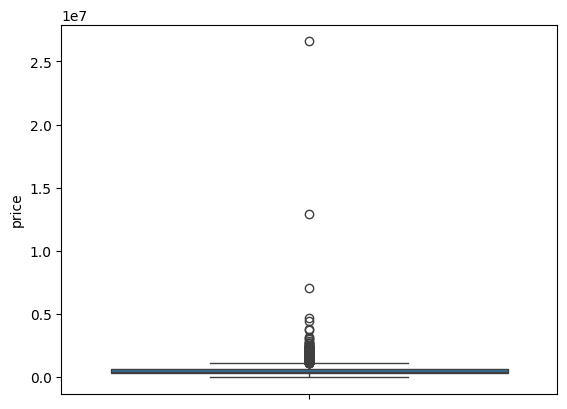

In [10]:
sns.boxplot(df["price"])
plt.show()

In [13]:
print(df.duplicated().sum())

0


In [15]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    # Corrected way to fill NaN values to avoid FutureWarni
    df.loc[:, col] = df[col].fillna(df[col].median())

In [16]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [17]:
print(df.duplicated().sum())

0


In [20]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())


0


In [21]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

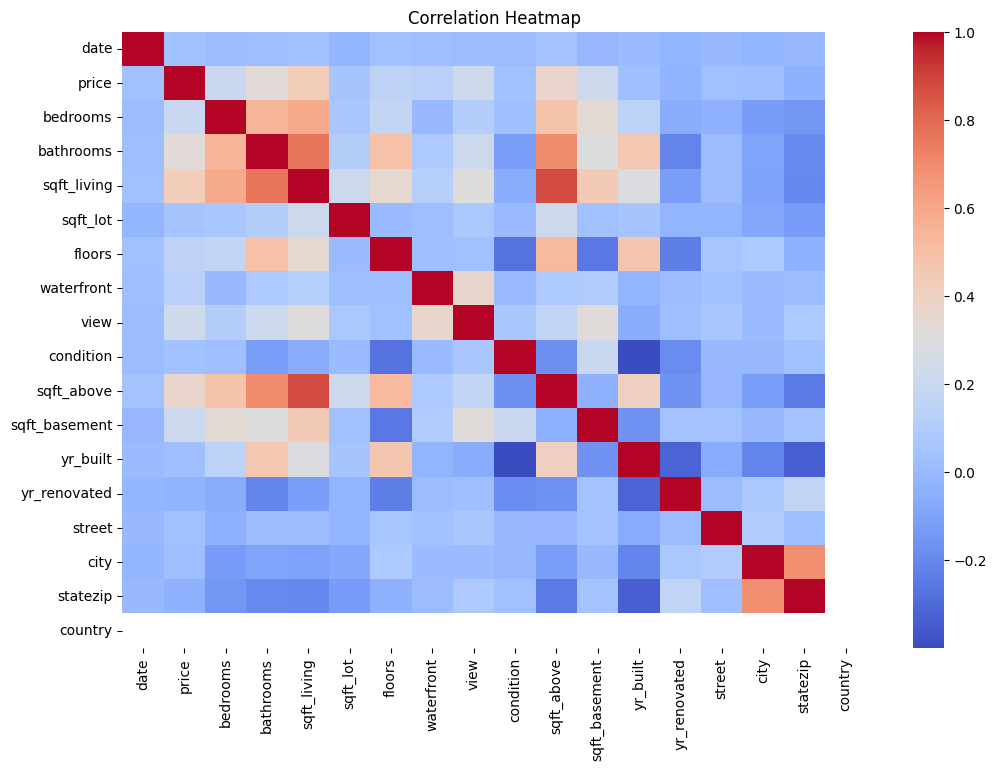

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

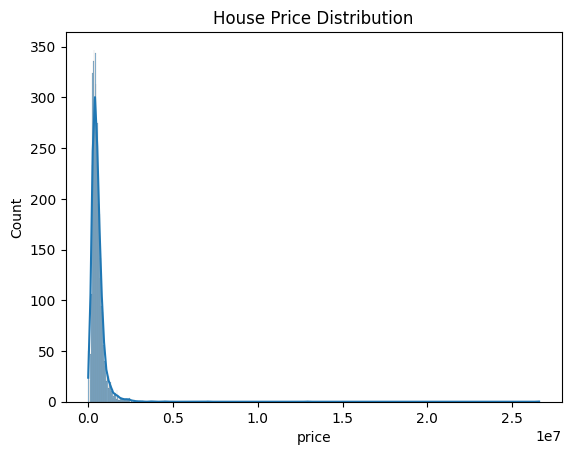

In [24]:
sns.histplot(df["price"], kde=True)

plt.title("House Price Distribution")
plt.show()

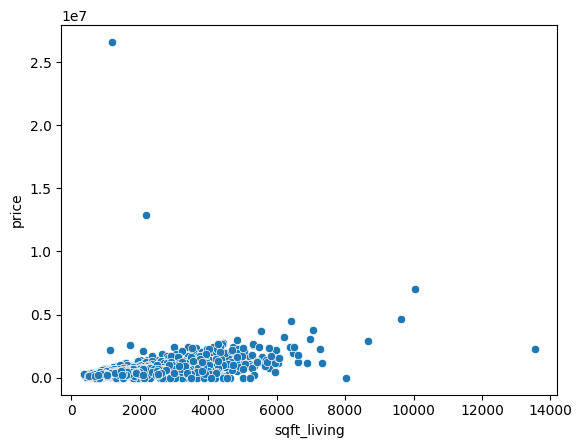

In [27]:
sns.scatterplot(x="sqft_living",
                y="price",
                data=df)

plt.show()

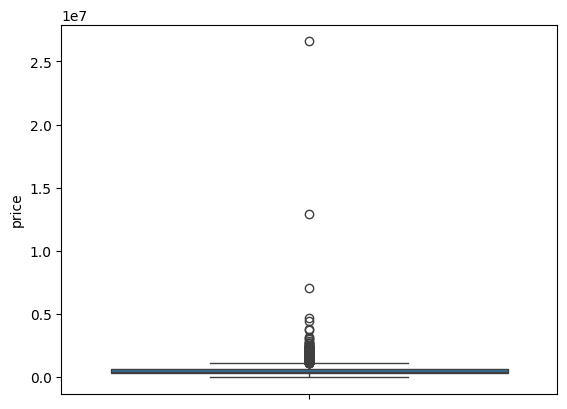

In [29]:

sns.boxplot(y=df["price"])

plt.show()


In [30]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()["price"]

top_corr = corr.abs().sort_values(
    ascending=False
).head(10)

print(top_corr)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
Name: price, dtype: float64


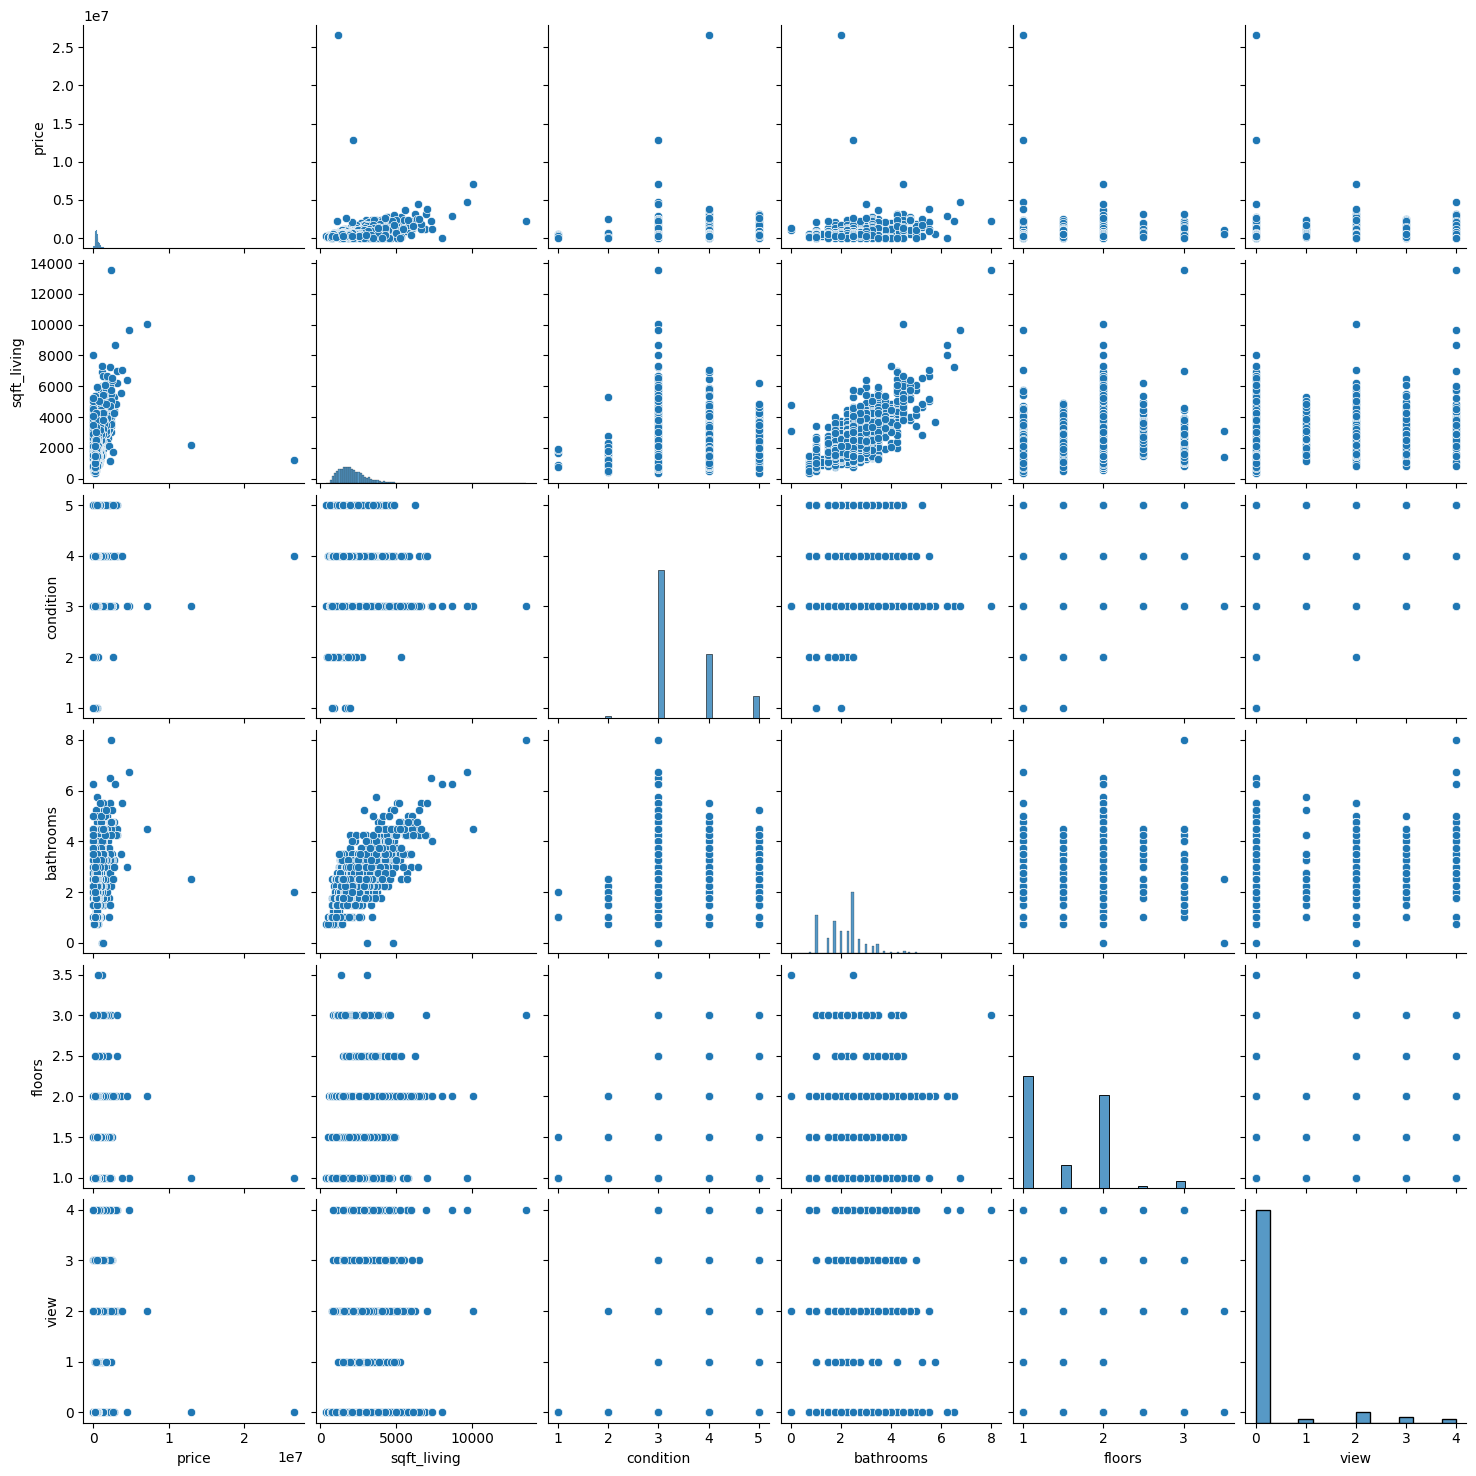

In [32]:
sns.pairplot(
    df[["price",
        "sqft_living",
        "condition",
        "bathrooms",
        "floors",
        "view"]]
)

plt.show()

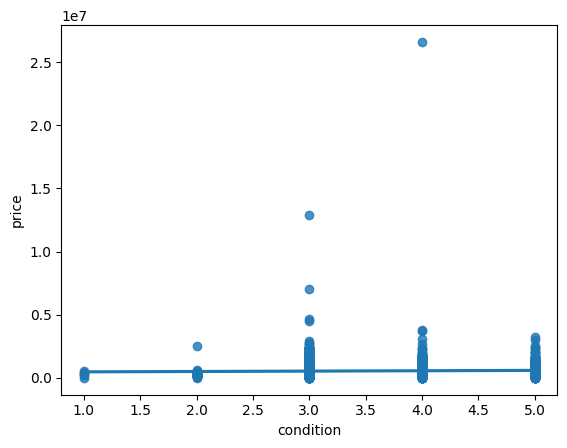

In [35]:
sns.regplot(x="condition",
            y="price",
            data=df)

plt.show()

In [42]:
y = df['price']
X = df.drop('price', axis=1)

In [43]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:",
      r2_score(y_test,pred_lr))

print("MAE:",
      mean_absolute_error(y_test,pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_lr)))

R2 Score: 0.03304504390209173
MAE: 207816.82941665532
RMSE: 993048.575350367


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [49]:
print("R2 Score:",
      r2_score(y_test,pred_rf))

print("MAE:",
      mean_absolute_error(y_test,pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_rf)))

R2 Score: 0.042455124089027074
MAE: 166991.39120465037
RMSE: 988204.7546773001


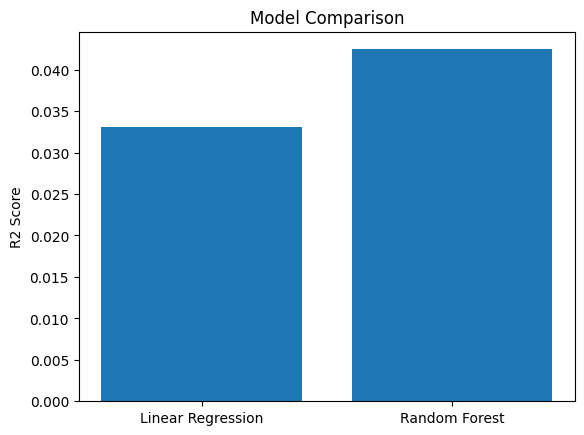

In [51]:
lr_r2 = r2_score(y_test,pred_lr)
rf_r2 = r2_score(y_test,pred_rf)

models = ["Linear Regression",
          "Random Forest"]

scores = [lr_r2,
          rf_r2]

plt.bar(models,scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [59]:
importance = rf.feature_importances_

feature_names = df.drop("price", axis=1).columns

feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feature_imp.head(10))

          Feature  Importance
3     sqft_living    0.518887
15       statezip    0.079082
11       yr_built    0.063101
14           city    0.049014
13         street    0.047336
9      sqft_above    0.041491
4        sqft_lot    0.041313
10  sqft_basement    0.038142
7            view    0.027803
2       bathrooms    0.025473


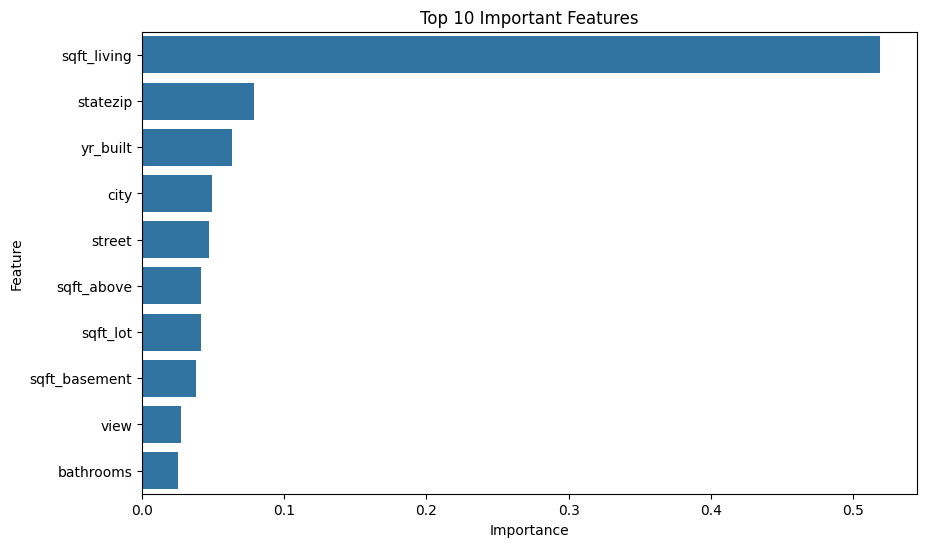

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_imp.head(10)["Importance"],
    y=feature_imp.head(10)["Feature"]
)

plt.title("Top 10 Important Features")

plt.show()